In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 00 — Data Preprocessing

Loads the raw **Homesite Quote Conversion** training CSV and produces a clean, model-ready tabular dataset for the downstream rolling-window experiment.

**Input:** `data/raw/train.csv` (Kaggle Homesite Quote Conversion)
**Output:** `data/processed/` with:
- `X.parquet` — full feature matrix
- `X_num.parquet` — numeric features only
- `X_bin.parquet` — binary features only
- `Y.npy` — binary labels (1 = converted)
- `meta.parquet` — `quote_date` + ids per row (chronological key)
- `feature_names.json` — `{all, num, bin, categorical_maps}`

**Pipeline steps:**
1. load the raw dataset
2. parse and inspect the temporal field
3. engineer a clean feature matrix (calendar, missingness indicators, ordinal encoding)
4. separate numeric vs binary features
5. save all downstream inputs in a fixed processed-data format
6. verify
7. exploratory data analysis


In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
# WORKSPACE : root folder for the entire pipeline (shared across model types)
# RAW_DIR   : where the raw Kaggle CSV lives (write-once)
# PROC_DIR  : final artefacts consumed by all downstream notebooks
# FIG_DIR   : EDA figures
WORKSPACE = Path('/content/drive/MyDrive/Homesite_workspace')
RAW_DIR   = WORKSPACE / 'data' / 'raw'
PROC_DIR  = WORKSPACE / 'data' / 'processed'
FIG_DIR   = PROC_DIR / 'figures'

for d in [RAW_DIR, PROC_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_CSV = RAW_DIR / 'train.csv'
print(f'RAW_CSV : {RAW_CSV}')
print(f'PROC_DIR: {PROC_DIR}')

RAW_CSV : /content/drive/MyDrive/Homesite_workspace/data/raw/train.csv
PROC_DIR: /content/drive/MyDrive/Homesite_workspace/data/processed


## 1. Load raw Homesite training data

In [4]:
df = pd.read_csv(RAW_CSV)

print(f'Raw shape: {df.shape}')
print(df.dtypes.value_counts())
df.head(3)

Raw shape: (260753, 299)
int64      265
object      28
float64      6
Name: count, dtype: int64


,QuoteNumber,Original_Quote_Date,QuoteConversion_Flag,Field6,Field7,Field8,Field9,Field10,Field11,Field12,...,GeographicField59A,GeographicField59B,GeographicField60A,GeographicField60B,GeographicField61A,GeographicField61B,GeographicField62A,GeographicField62B,GeographicField63,GeographicField64
0,1,2013-08-16,0,B,23,0.9403,0.0006,965,1.0200,N,...,9,9,-1,8,-1,18,-1,10,N,CA
1,2,2014-04-22,0,F,7,1.0006,0.0040,548,1.2433,N,...,10,10,-1,11,-1,17,-1,20,N,NJ
2,4,2014-08-25,0,F,7,1.0006,0.0040,548,1.2433,N,...,15,18,-1,21,-1,11,-1,8,N,NJ


In [5]:
# Sanity check on the three columns the rest of the pipeline depends on:
#   QuoteNumber           — stable per-row identifier
#   Original_Quote_Date   — temporal key for rolling windows
#   QuoteConversion_Flag  — binary target
required_cols = ['QuoteNumber', 'Original_Quote_Date', 'QuoteConversion_Flag']
missing_required = [c for c in required_cols if c not in df.columns]
assert not missing_required, f'Missing required columns: {missing_required}'

df['Original_Quote_Date'] = pd.to_datetime(df['Original_Quote_Date'], errors='coerce')
assert df['Original_Quote_Date'].notna().all(), 'Unparseable dates found in Original_Quote_Date'

# Chronological sort + stable row_id — every downstream notebook indexes by this row order.
df = df.sort_values(['Original_Quote_Date', 'QuoteNumber']).reset_index(drop=True)
df['row_id'] = np.arange(len(df), dtype=np.int64)

print(f'Date range   : {df["Original_Quote_Date"].min()} → {df["Original_Quote_Date"].max()}')
print(f'Positive rate: {df["QuoteConversion_Flag"].mean():.4f}')
print(f'Rows         : {len(df):,}')

Date range   : 2013-01-01 00:00:00 → 2015-05-18 00:00:00
Positive rate: 0.1875
Rows         : 260,753


## 2. Build metadata table

`meta.parquet` is the chronological spine of the whole pipeline. It stores the parsed quote date, the label, and the stable row identity used by the rolling-window setup.

In [6]:
meta = df[['row_id', 'QuoteNumber', 'Original_Quote_Date', 'QuoteConversion_Flag']].rename(
    columns={
        'Original_Quote_Date': 'quote_date',
        'QuoteConversion_Flag': 'label',
    }
).copy()

meta['year']  = meta['quote_date'].dt.year.astype(np.int16)
meta['month'] = meta['quote_date'].dt.month.astype(np.int8)

print(meta.head(3))
print()
print(meta.dtypes)

   row_id  QuoteNumber quote_date  label  year  month
0       0         3489 2013-01-01      0  2013      1
1       1        24916 2013-01-01      0  2013      1
2       2        25137 2013-01-01      0  2013      1

row_id                  int64
QuoteNumber             int64
quote_date     datetime64[ns]
label                   int64
year                    int16
month                    int8
dtype: object


## 3. Define raw feature groups

The target, identifier, and temporal fields are excluded from the model matrix.
All remaining columns are treated as candidate predictors and are split into numeric and object groups before feature engineering.

In [7]:
drop_from_X = ['row_id', 'QuoteNumber', 'Original_Quote_Date', 'QuoteConversion_Flag']
feature_source = df.drop(columns=drop_from_X).copy()

obj_cols     = feature_source.select_dtypes(include='object').columns.tolist()
num_cols_raw = [c for c in feature_source.columns if c not in obj_cols]

print(f'Total candidate features      : {feature_source.shape[1]}')
print(f'Numeric (int/float) columns   : {len(num_cols_raw)}')
print(f'Object columns (to be encoded): {len(obj_cols)}')
print(obj_cols)

Total candidate features      : 296
Numeric (int/float) columns   : 269
Object columns (to be encoded): 27
['Field6', 'Field10', 'Field12', 'CoverageField8', 'CoverageField9', 'SalesField7', 'PersonalField7', 'PersonalField16', 'PersonalField17', 'PersonalField18', 'PersonalField19', 'PropertyField3', 'PropertyField4', 'PropertyField5', 'PropertyField7', 'PropertyField14', 'PropertyField28', 'PropertyField30', 'PropertyField31', 'PropertyField32', 'PropertyField33', 'PropertyField34', 'PropertyField36', 'PropertyField37', 'PropertyField38', 'GeographicField63', 'GeographicField64']


## 4. Feature Engineering

1. derive calendar features from `Original_Quote_Date`
2. create missing-value indicators where needed
3. encode object columns into deterministic integer codes
4. cast everything to compact numeric dtypes
5. split the final matrix into numeric and binary subsets

In [8]:
# Calendar features: the rolling-window experiment uses a monthly time step, but per-row
# calendar features (day-of-week, day-of-year, etc.) can still help the models within a window.
date_feats = pd.DataFrame({
    'quote_year':            df['Original_Quote_Date'].dt.year.astype(np.int16),
    'quote_month':           df['Original_Quote_Date'].dt.month.astype(np.int8),
    'quote_day':             df['Original_Quote_Date'].dt.day.astype(np.int8),
    'quote_dayofweek':       df['Original_Quote_Date'].dt.dayofweek.astype(np.int8),
    'quote_dayofyear':       df['Original_Quote_Date'].dt.dayofyear.astype(np.int16),
    'quote_weekofyear':      df['Original_Quote_Date'].dt.isocalendar().week.astype(np.int16),
    'quote_quarter':         df['Original_Quote_Date'].dt.quarter.astype(np.int8),
    'quote_is_month_start':  df['Original_Quote_Date'].dt.is_month_start.astype(np.int8),
    'quote_is_month_end':    df['Original_Quote_Date'].dt.is_month_end.astype(np.int8),
    'quote_is_quarter_start':df['Original_Quote_Date'].dt.is_quarter_start.astype(np.int8),
    'quote_is_quarter_end':  df['Original_Quote_Date'].dt.is_quarter_end.astype(np.int8),
    'quote_is_weekend':      (df['Original_Quote_Date'].dt.dayofweek >= 5).astype(np.int8),
})
date_feats.head(3)

,quote_year,quote_month,quote_day,quote_dayofweek,quote_dayofyear,quote_weekofyear,quote_quarter,quote_is_month_start,quote_is_month_end,quote_is_quarter_start,quote_is_quarter_end,quote_is_weekend
0,2013,1,1,1,1,1,1,1,0,1,0,0
1,2013,1,1,1,1,1,1,1,0,1,0,0
2,2013,1,1,1,1,1,1,1,0,1,0,0


In [9]:
# Missing-value indicators: Homesite has meaningful missingness patterns, so we
# preserve them as explicit binary indicators alongside the imputed values.
missing_rates = feature_source.isna().mean().sort_values(ascending=False)
missing_cols  = missing_rates[missing_rates > 0].index.tolist()

missing_indicators = pd.DataFrame(index=feature_source.index)
for c in missing_cols:
    missing_indicators[f'{c}__missing'] = feature_source[c].isna().astype(np.int8)

print(f'Columns with missing values: {len(missing_cols)}')
print(missing_rates[missing_rates > 0].head(15))

Columns with missing values: 9
PropertyField29    0.769636
PersonalField84    0.476344
PropertyField38    0.004679
PersonalField7     0.000433
PropertyField36    0.000433
PropertyField3     0.000311
PropertyField32    0.000268
PropertyField34    0.000268
PropertyField4     0.000242
dtype: float64


In [10]:
# Ordinal encoding: deterministic alphabetical mapping per column. We save the
# mapping in feature_names.json so downstream notebooks can decode if needed.
encoded_obj = pd.DataFrame(index=feature_source.index)
categorical_maps = {}

for c in obj_cols:
    s = feature_source[c].astype('string').fillna('__MISSING__')
    cats = sorted(pd.Series(s.unique()).astype(str).tolist())
    mapping = {v: i for i, v in enumerate(cats)}
    encoded_obj[c] = s.map(mapping).astype(np.int32)
    categorical_maps[c] = mapping

encoded_obj.head(3)

,Field6,Field10,Field12,CoverageField8,CoverageField9,SalesField7,PersonalField7,PersonalField16,PersonalField17,PersonalField18,...,PropertyField30,PropertyField31,PropertyField32,PropertyField33,PropertyField34,PropertyField36,PropertyField37,PropertyField38,GeographicField63,GeographicField64
0,1,7,0,0,9,3,0,28,48,15,...,0,3,1,3,0,0,0,0,1,0
1,1,7,0,0,9,2,0,28,48,15,...,0,0,1,3,1,0,0,0,1,0
2,6,1,0,0,6,2,0,28,48,15,...,0,0,0,2,0,0,0,0,1,3


In [11]:
# Numeric imputation: -1 sentinel keeps the column type tight and the missing
# pattern is already preserved by the indicator columns above.
numeric_part = feature_source[num_cols_raw].copy()

for c in numeric_part.columns:
    if pd.api.types.is_float_dtype(numeric_part[c]):
        numeric_part[c] = numeric_part[c].fillna(-1).astype(np.float32)
    else:
        numeric_part[c] = numeric_part[c].fillna(-1).astype(np.int32)

X_base = pd.concat(
    [
        numeric_part.reset_index(drop=True),
        encoded_obj.reset_index(drop=True),
        missing_indicators.reset_index(drop=True),
        date_feats.reset_index(drop=True),
    ],
    axis=1,
)

assert X_base.shape[0] == len(df)
assert not X_base.isnull().any().any(), 'NaN values in X_base!'

print(f'X_base shape: {X_base.shape}')
X_base.head(3)

X_base shape: (260753, 317)


,Field7,Field8,Field9,Field11,CoverageField1A,CoverageField1B,CoverageField2A,CoverageField2B,CoverageField3A,CoverageField3B,...,quote_day,quote_dayofweek,quote_dayofyear,quote_weekofyear,quote_quarter,quote_is_month_start,quote_is_month_end,quote_is_quarter_start,quote_is_quarter_end,quote_is_weekend
0,6,0.9219,0.0006,1.0000,8,14,8,14,7,12,...,1,1,1,1,1,1,0,1,0,0
1,23,0.9219,0.0006,1.0000,25,25,25,25,25,25,...,1,1,1,1,1,1,0,1,0,0
2,23,0.9559,0.0004,1.2392,21,24,21,24,19,24,...,1,1,1,1,1,1,0,1,0,0


In [12]:
# Split into numeric / binary views. Downstream notebooks (especially MLP-PLR)
# treat the two groups differently: numeric cols get scaled / embedded, binary
# cols are passed through unchanged.
binary_cols  = [c for c in X_base.columns if X_base[c].nunique(dropna=False) == 2]
numeric_cols = [c for c in X_base.columns if c not in binary_cols]

X_num = X_base[numeric_cols].copy()
X_bin = X_base[binary_cols].copy()

# Compact dtypes
for c in X_num.columns:
    if pd.api.types.is_float_dtype(X_num[c]):
        X_num[c] = X_num[c].astype(np.float32)
    else:
        X_num[c] = X_num[c].astype(np.int32)
for c in X_bin.columns:
    X_bin[c] = X_bin[c].astype(np.int8)

print(f'X_num shape    : {X_num.shape}')
print(f'X_bin shape    : {X_bin.shape}')
print(f'Binary columns : {len(binary_cols)}')

X_num shape    : (260753, 280)
X_bin shape    : (260753, 37)
Binary columns : 37


## 5. Assemble and save final dataset

In [13]:
# Concatenate to single matrix; the column order is fixed by feature_names['all']
# and is the canonical column order used by every downstream notebook.
X = pd.concat([X_num, X_bin], axis=1)
Y = meta['label'].values.astype(np.int8)

feature_names     = list(X.columns)
num_feature_names = list(X_num.columns)
bin_feature_names = list(X_bin.columns)

assert len(X) == len(Y) == len(meta), 'Row count mismatch'
assert not X.isnull().any().any(), 'NaN values found in X'
assert set(feature_names) == set(num_feature_names) | set(bin_feature_names)

print(f'X    : {X.shape}')
print(f'Y    : {Y.shape}  positives={Y.sum():,} ({Y.mean():.3%})')
print(f'meta : {meta.shape}')

X    : (260753, 317)
Y    : (260753,)  positives=48,894 (18.751%)
meta : (260753, 6)


In [14]:
X.to_parquet(PROC_DIR / 'X.parquet', index=False)
X_num.to_parquet(PROC_DIR / 'X_num.parquet', index=False)
X_bin.to_parquet(PROC_DIR / 'X_bin.parquet', index=False)
np.save(PROC_DIR / 'Y.npy', Y)
meta.to_parquet(PROC_DIR / 'meta.parquet', index=False)

with open(PROC_DIR / 'feature_names.json', 'w') as f:
    json.dump(
        {
            'all': feature_names,
            'num': num_feature_names,
            'bin': bin_feature_names,
            'categorical_maps': categorical_maps,
        },
        f,
        indent=2,
    )

print('Saved files:')
for fname in ['X.parquet', 'X_num.parquet', 'X_bin.parquet', 'Y.npy', 'meta.parquet', 'feature_names.json']:
    p = PROC_DIR / fname
    print(f'  {fname:<22s} {p.stat().st_size / 1e6:8.2f} MB')

Saved files:
  X.parquet                 31.20 MB
  X_num.parquet             30.68 MB
  X_bin.parquet              0.52 MB
  Y.npy                      0.26 MB
  meta.parquet               2.93 MB
  feature_names.json         0.02 MB


## 6. Verification

In [15]:
X_check     = pd.read_parquet(PROC_DIR / 'X.parquet')
X_num_check = pd.read_parquet(PROC_DIR / 'X_num.parquet')
X_bin_check = pd.read_parquet(PROC_DIR / 'X_bin.parquet')
Y_check     = np.load(PROC_DIR / 'Y.npy')
meta_check  = pd.read_parquet(PROC_DIR / 'meta.parquet')

with open(PROC_DIR / 'feature_names.json') as f:
    fn_check = json.load(f)

assert X_check.shape[0] == Y_check.shape[0] == meta_check.shape[0]
assert X_num_check.shape[0] == X_bin_check.shape[0] == X_check.shape[0]
assert X_check.shape[1] == len(fn_check['all'])
assert X_num_check.shape[1] == len(fn_check['num'])
assert X_bin_check.shape[1] == len(fn_check['bin'])
assert not X_check.isnull().any().any()
assert pd.api.types.is_datetime64_any_dtype(meta_check['quote_date'])

print(f'X      : {X_check.shape}')
print(f'X_num  : {X_num_check.shape}')
print(f'X_bin  : {X_bin_check.shape}')
print(f'Y      : {Y_check.shape}')
print(f'meta   : {meta_check.shape}')
print(f'Date range: {meta_check["quote_date"].min()} → {meta_check["quote_date"].max()}')
print('All checks passed.')

X      : (260753, 317)
X_num  : (260753, 280)
X_bin  : (260753, 37)
Y      : (260753,)
meta   : (260753, 6)
Date range: 2013-01-01 00:00:00 → 2015-05-18 00:00:00
All checks passed.


---
## 7. Exploratory Data Analysis

Build intuition about the Homesite dataset before modelling and confirm that the temporal field, class balance, and feature matrix all look sensible for the rolling-window experiment.

In [16]:
print('=' * 60)
print('TRAINING SET OVERVIEW')
print('=' * 60)
print(f'Total quotes              : {len(df):,}')
print(f'Unique QuoteNumber values : {df["QuoteNumber"].nunique():,}')
print(f'Date range                : {df["Original_Quote_Date"].min().date()} → {df["Original_Quote_Date"].max().date()}')
print(f'Positive rate             : {df["QuoteConversion_Flag"].mean():.3%}')
print(f'Number of raw predictors  : {feature_source.shape[1]}')
print(f'Processed feature count   : {X.shape[1]}')
print()
label_counts = meta['label'].value_counts().sort_index()
label_pct    = meta['label'].value_counts(normalize=True).sort_index() * 100
for lbl, cnt, pct in zip(label_counts.index, label_counts.values, label_pct.values):
    name = 'Converted (1)' if lbl == 1 else 'Not converted (0)'
    print(f'  {name:18s}: {cnt:8,} ({pct:5.2f}%)')

TRAINING SET OVERVIEW
Total quotes              : 260,753
Unique QuoteNumber values : 260,753
Date range                : 2013-01-01 → 2015-05-18
Positive rate             : 18.751%
Number of raw predictors  : 296
Processed feature count   : 317

  Not converted (0) :  211,859 (81.25%)
  Converted (1)     :   48,894 (18.75%)


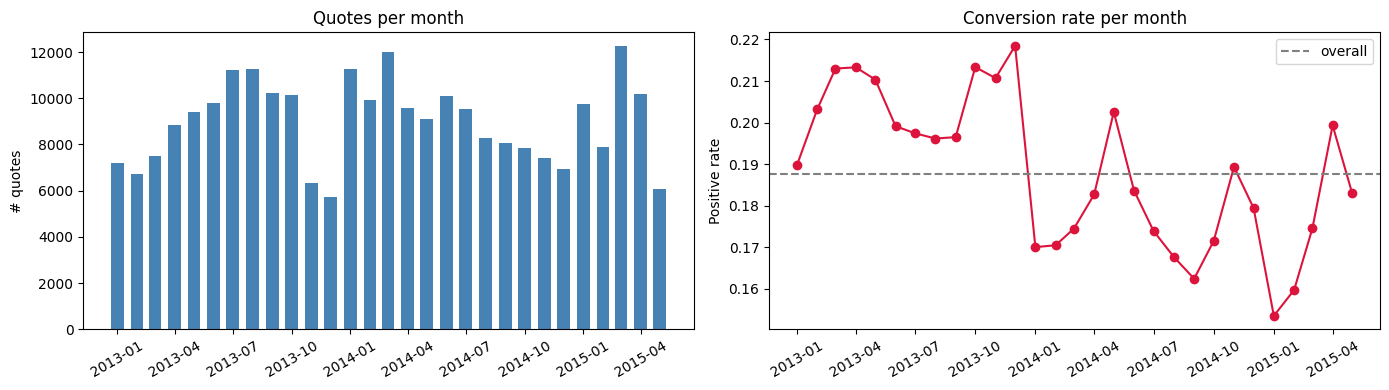

     month  n_quotes  n_positive  positive_rate
2013-01-01      7195        1365       0.189715
2013-02-01      6744        1370       0.203144
2013-03-01      7493        1596       0.212999
2013-04-01      8833        1884       0.213291
2013-05-01      9413        1980       0.210347
2013-06-01      9798        1951       0.199122
2013-07-01     11241        2219       0.197402
2013-08-01     11272        2211       0.196150
2013-09-01     10245        2013       0.196486
2013-10-01     10148        2165       0.213343
2013-11-01      6336        1335       0.210701
2013-12-01      5740        1254       0.218467


In [17]:
# Volume + positive rate per calendar month — gives a feel for how many rows each
# rolling-window time step will hold.
monthly = (
    meta.assign(month=meta['quote_date'].dt.to_period('M').dt.to_timestamp())
        .groupby('month')
        .agg(n_quotes=('label', 'size'), n_positive=('label', 'sum'))
        .reset_index()
)
monthly['positive_rate'] = monthly['n_positive'] / monthly['n_quotes']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(monthly['month'], monthly['n_quotes'], width=20, color='steelblue')
axes[0].set_title('Quotes per month')
axes[0].set_ylabel('# quotes')
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(monthly['month'], monthly['positive_rate'], marker='o', color='crimson')
axes[1].set_title('Conversion rate per month')
axes[1].set_ylabel('Positive rate')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(meta['label'].mean(), linestyle='--', color='gray', label='overall')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'volume_and_rate_per_month.png', dpi=120)
plt.show()

print(monthly.head(12).to_string(index=False))

In [18]:
# Top missing-value columns — sanity check that the indicator features cover the worst offenders.
missing_summary = (feature_source.isna().mean()
                   .sort_values(ascending=False)
                   .head(15)
                   .rename('missing_rate')
                   .to_frame())
print('Top 15 columns by missing rate:')
print(missing_summary.to_string())

Top 15 columns by missing rate:
                    missing_rate
PropertyField29         0.769636
PersonalField84         0.476344
PropertyField38         0.004679
PersonalField7          0.000433
PropertyField36         0.000433
PropertyField3          0.000311
PropertyField32         0.000268
PropertyField34         0.000268
PropertyField4          0.000242
GeographicField17B      0.000000
GeographicField16B      0.000000
GeographicField16A      0.000000
GeographicField15B      0.000000
GeographicField15A      0.000000
GeographicField14B      0.000000


In [19]:
# Class balance + first-glance feature distribution check.
print(f'Class imbalance ratio (neg:pos): '
      f'{(Y == 0).sum() / max((Y == 1).sum(), 1):.2f}:1')
print()
print('Feature summary (numeric columns, first 8):')
print(X_num.iloc[:, :8].describe().T[['mean', 'std', 'min', 'max']].round(3).to_string())

Class imbalance ratio (neg:pos): 4.33:1

Feature summary (numeric columns, first 8):
                   mean    std    min     max
Field7           18.293  7.383  1.000  28.000
Field8            0.938  0.037  0.875   1.010
Field9            0.001  0.001  0.000   0.004
Field11           1.163  0.117  1.000   1.304
CoverageField1A   9.013  5.577 -1.000  25.000
CoverageField1B  13.000  7.219 -1.000  25.000
CoverageField2A   9.054  5.561  1.000  25.000
CoverageField2B  13.015  7.212  1.000  25.000
